In [2]:
library(data.table)
library(dplyr)
library(ggplot2)
library(purrr)

options(repr.plot.width = 12, repr.plot.height = 6)  # largeur=12 pouces, hauteur=6 pouces


Attaching package: 'dplyr'


The following objects are masked from 'package:data.table':

    between, first, last


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union



Attaching package: 'purrr'


The following object is masked from 'package:data.table':

    transpose




In [4]:
doPCF <- function(baf, chr, pos=1:length(baf), minEvents=1, gamma = 1)
{
  require(copynumber)
  res <- pcf(data.frame(chr=rep(chr,length(baf)),
                        positions=pos,
                        sample1=baf),
             verbose=F,
             kmin=minEvents,
            gamma=gamma)
  res
}  
                           
                           
get_baf <- function(sample, chr, allele_count, beagle, output_path = NA, plot=FALSE){
    
    output_baf =  paste0(output_path,"baf_chr",as.character(chr),"_",sample,".txt")
    if(file.exists(output_baf)){
        baf = fread(output_baf, sep = "\t", header=T, data.table=F)
        return(baf)
    }
    #message("  >> BAF computing [CHR",chr,"]...")
    allele_count = fread(allele_count,header = T, sep = '\t',data.table=F)

    phases = readPhases(beagle)
    colnames(phases)[1:2] = colnames(allele_count)[1:2]
    phases <- phases[order(phases$POS,decreasing = F), ]
    
    baf = merge(phases, allele_count, by = c("#CHR", "POS"))

    baf$BAF_phase1 = rep(0, nrow(baf))
    baf$BAF_phase1[baf$phase1 == "A"] = baf$Count_A[baf$phase1 == "A"]
    baf$BAF_phase1[baf$phase1 == "C"] = baf$Count_C[baf$phase1 == "C"]
    baf$BAF_phase1[baf$phase1 == "G"] = baf$Count_G[baf$phase1 == "G"]
    baf$BAF_phase1[baf$phase1 == "T"] = baf$Count_T[baf$phase1 == "T"]
    baf$BAF_phase1 = baf$BAF_phase1/baf$Good_depth


    baf$BAF_phase2 = rep(0, nrow(baf))
    baf$BAF_phase2[baf$phase2 == "A"] = baf$Count_A[baf$phase2 == "A"]
    baf$BAF_phase2[baf$phase2 == "C"] = baf$Count_C[baf$phase2 == "C"]
    baf$BAF_phase2[baf$phase2 == "G"] = baf$Count_G[baf$phase2 == "G"]
    baf$BAF_phase2[baf$phase2 == "T"] = baf$Count_T[baf$phase2 == "T"]
    baf$BAF_phase2 = baf$BAF_phase2/baf$Good_depth

    baf[is.na(baf)] <- 0
    baf <- baf[order(baf$POS,decreasing = F), ]

    if (!is.na(output_path)){
        write.table(baf, output_baf,sep = "\t", col.names = TRUE,row.names=FALSE, quote=FALSE)
    }
    
    if (plot == TRUE){
        
        BAF_plot = ggplot(data = baf, aes(x = POS, y = BAF_phase1)) +
      geom_point(size=0.05,fill='grey') +
      geom_hline(yintercept=0.5, linetype="dashed", color = "red")+
      scale_x_continuous(labels = function(x) x/1000000, name = "SNPs position (Mb)")+
      theme(plot.title = element_text(hjust = 0.5))

      ggsave(filename = gsub("txt","png",output_baf), plot = BAF_plot, width = 6, height = 4, dpi = 300)
      
    }
                        
    return(baf)
}
 
                         
readPhases <- function(x){
    x[,10] = sub(":.*", "", x[,10] )
    x <- x[x[,10]%in%c("0|1","1|0"),]
    phase1 <- gsub("(.*)\\|(.*)","\\1",x[,10])
    phase2 <- gsub("(.*)\\|(.*)","\\2",x[,10])
    phases1 <- x[,"REF"]
    phases1[phase1=="1"] <- x[phase1=="1","ALT"]
    phases2 <- x[,"REF"]
    phases2[phase2=="1"] <- x[phase2=="1","ALT"]
    phases = data.frame(chr=x[,1],
                         pos=x[,2],
                         phase1=phases1,
                         phase2=phases2)
    return(phases)
}

In [5]:
compute_SE_IZ <- function(segment_CN, 
                                  segment_beagle,
                                  chr,
                                  minor_cn, major_cn, total_cn,
                                  gamma = 10,
                                  minEvents = 10,
                                  llr_thresh = -2,
                                  min_run = 5,
                                  window = 21,
                                  plot_result = TRUE) {
  
  # ---------- STEP 1: PCF-based block flipping ----------
  pcf <- doPCF(segment_CN$BAF_phase1, chr = chr, minEvents = minEvents, gamma = gamma)
  pcf_switch <- subset(pcf, mean < 0.5)
  
  in_pcf_switch <- rep(FALSE, nrow(segment_CN))
  if (nrow(pcf_switch) > 0) {
    for (r in seq_len(nrow(pcf_switch))) {
      start_pos <- pcf_switch$start.pos[r]
      end_pos   <- pcf_switch$end.pos[r]
      in_pcf_switch[start_pos:end_pos] <- TRUE
    }
  }
  
  # Initialisation des colonnes bloc
  segment_CN$phase1_block <- segment_CN$phase1
  segment_CN$phase2_block <- segment_CN$phase2
  segment_CN$BAF_phase1_block <- segment_CN$BAF_phase1
  segment_CN$BAF_phase2_block <- segment_CN$BAF_phase2
  
  if (any(in_pcf_switch)) {
    rle_mask <- rle(in_pcf_switch)
    ends <- cumsum(rle_mask$lengths)
    starts <- c(1, head(ends, -1) + 1)
    for (i in seq_along(rle_mask$values)) {
      if (rle_mask$values[i]) {
        idx_block <- starts[i]:ends[i]
        # swap block
        tmp1 <- segment_CN$phase1_block[idx_block]
        segment_CN$phase1_block[idx_block] <- segment_CN$phase2_block[idx_block]
        segment_CN$phase2_block[idx_block] <- tmp1
        tmpb1 <- segment_CN$BAF_phase1_block[idx_block]
        segment_CN$BAF_phase1_block[idx_block] <- segment_CN$BAF_phase2_block[idx_block]
        segment_CN$BAF_phase2_block[idx_block] <- tmpb1
      }
    }
  }
  
  # ---------- STEP 2: SNP-level refinement using LLR ----------
  count1 <- round(segment_CN$BAF_phase1_block * segment_CN$Good_depth)
  count2 <- round(segment_CN$BAF_phase2_block * segment_CN$Good_depth)
  n_all  <- count1 + count2
  
  llr_vec <- mapply(function(k, n, a1, a2, minor_cn, major_cn, total_cn) {
    p1 <- (major_cn * a1 + minor_cn * a2) / total_cn
    p2 <- (minor_cn * a1 + major_cn * a2) / total_cn
    p1 <- pmin(pmax(p1, 1e-8), 1 - 1e-8)
    p2 <- pmin(pmax(p2, 1e-8), 1 - 1e-8)
    k * log(p1 / p2) + (n - k) * log((1 - p1) / (1 - p2))
  }, k = count1, n = n_all, a1 = segment_CN$BAF_phase1_block, 
  a2 = segment_CN$BAF_phase2_block,
  minor_cn = minor_cn, major_cn = major_cn, total_cn = total_cn)
  
  segment_CN$llr_post_block <- llr_vec
  
  # Lissage LLR
  llr_smooth <- stats::filter(segment_CN$llr_post_block, rep(1 / window, window), sides = 2)
  llr_smooth[is.na(llr_smooth)] <- segment_CN$llr_post_block[is.na(llr_smooth)]
  segment_CN$llr_smooth <- as.numeric(llr_smooth)
  
  # SNPs à inverser
  candidate_snps <- which(segment_CN$llr_smooth < llr_thresh & n_all > 0)
  
  # Fusion des runs contigus
  cand_rle <- rle(seq_along(segment_CN$llr_smooth) %in% candidate_snps)
  ends <- cumsum(cand_rle$lengths)
  starts <- c(1, head(ends, -1) + 1)
  for (i in seq_along(cand_rle$values)) {
    if (cand_rle$values[i]) {
      idx_run <- starts[i]:ends[i]
      if (length(idx_run) >= min_run) {
        tmp1 <- segment_CN$phase1_block[idx_run]
        segment_CN$phase1_block[idx_run] <- segment_CN$phase2_block[idx_run]
        segment_CN$phase2_block[idx_run] <- tmp1
        tmpb1 <- segment_CN$BAF_phase1_block[idx_run]
        segment_CN$BAF_phase1_block[idx_run] <- segment_CN$BAF_phase2_block[idx_run]
        segment_CN$BAF_phase2_block[idx_run] <- tmpb1
      }
    }
  }
  
    # ---------- Résultats finaux ----------
    segment_CN$phase1_corrected <- segment_CN$phase1_block
    segment_CN$phase2_corrected <- segment_CN$phase2_block
    segment_CN$BAF_phase1_corrected <- segment_CN$BAF_phase1_block
    segment_CN$BAF_phase2_corrected <- segment_CN$BAF_phase2_block
    segment_CN$switch <- segment_CN$phase1 != segment_CN$phase1_corrected

    rle_mask <- rle(segment_CN$switch)
    ends <- cumsum(rle_mask$lengths)
    SE_rate <- (length(ends) - 1) / nrow(segment_CN) * 100

    switch_pos <- segment_CN$POS[segment_CN$switch == TRUE]

    if (plot_result) {
      # Plot 1: BAF corrigée
      plot_corrected <- ggplot(segment_CN, aes(x = POS, y = BAF_phase1_corrected)) +
        geom_point(color = "black", size = 1.5) +
        geom_point(data = subset(segment_CN, POS %in% switch_pos),
                   aes(x = POS, y = BAF_phase1_corrected),
                   color = "red", size = 1.5) +
        geom_vline(xintercept = segment_CN$POS[ends], color = "blue", linetype = "dashed") +
        labs(
          title = paste0("BAF Phase1 Corrected (SE_rate = ", round(SE_rate, 2), "%)"),
          x = "POS",
          y = "BAF Phase1 Corrected"
        ) +
        theme_bw()

      # Plot 2: BAF non corrigée
      plot_uncorrected <- ggplot(segment_CN, aes(x = POS, y = BAF_phase1)) +
        geom_point(color = "black", size = 1.5) +
        geom_point(data = subset(segment_CN, POS %in% switch_pos),
                   aes(x = POS, y = BAF_phase1),
                   color = "red", size = 1.5) +
        geom_vline(xintercept = segment_CN$POS[ends], color = "blue", linetype = "dashed") +
        labs(
          title = paste0("BAF Phase1 Uncorrected (SE_rate = ", round(SE_rate, 2), "%)"),
          x = "POS",
          y = "BAF Phase1 Uncorrected"
        ) +
        theme_bw()

      # Stocke les plots
      plots <- list(corrected = plot_corrected, uncorrected = plot_uncorrected)
    } else {
      plots <- NULL
    }

    return(list(segment_CN = segment_CN, SE_rate = SE_rate, plots = plots))


}


# Correct phasing

In [6]:
sample = "74039acd-5aca-4c65-818c-3b577d295be0"

### Low coverage 1kGp phasing

In [7]:
input_path_PCAWG = read.table("/srv/home/mlef0011/Phasomix/output/local_ancestry/prediction/high_coverage/IS_corrected/input_path_F1_like_mono_x_admixed_gnomix_PCAWG_POP_no_AMR.tsv", header=T, sep = "\t")
samples = input_path_PCAWG$sample

chr = 8


allecount_path <- paste0("/mnt/iribhm/globus/secure/PCAWG_alleleCounts/", sample, "/", sample, "_alleleFrequencies_chr", chr, ".txt.gz")

beagle_mixed_ancestry = fread("/srv/home/mlef0011/Phasomix/rawdata/PCAWG/rawdata/chr8_PCAWG_beagle5_subset_1kgp_PCAWG_snp_phased_1kGp_unrelared_IDs_low_coverage_reference_panel.vcf.gz", select = c('#CHROM','POS','ID','REF','ALT','QUAL','FILTER','INFO','FORMAT',sample), skip = "#CHROM", header=T, sep = "\t", data.table=F)
beagle_raw <- beagle_mixed_ancestry[, c(colnames(beagle_mixed_ancestry)[1:9], sample)]
beagle <- beagle_raw[beagle_raw[[ncol(beagle_raw)]] != "0|0", ]

baf_raw <- get_baf(sample, chr, allecount_path, beagle)


common_pos <- intersect(beagle$POS, baf_raw$POS)

beagle <- beagle[match(common_pos, beagle$POS), ]
baf <- baf_raw[match(common_pos, baf_raw$POS), ]

colnames(beagle)[ncol(beagle)] = sample
corrected_beagle_correction_1 = beagle
corrected_beagle_correction_2 = beagle


cna_file = input_path_PCAWG[input_path_PCAWG$sample == sample , "input_CNA"]
cna <- fread(cna_file, sep = '\t', data.table = FALSE)
iz = subset(cna, chromosome == chr & !is.na(major_cn) & !is.na(minor_cn) & minor_cn != major_cn)[,1:6]

idx = 1
start = iz[idx,2]
end = iz[idx,3]
minor_cn = iz[idx,5]
major_cn = iz[idx,6]
total_cn = iz[idx,4]

segment_beagle = subset(beagle, beagle$'#CHROM' == chr & beagle$POS >= start & beagle$POS <= end)
segment_CN = subset(baf, beagle$'#CHR' == chr & baf$POS >= start & baf$POS <= end)

Loading required package: copynumber

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: 'generics'


The following object is masked from 'package:dplyr':

    explain


The following objects are masked from 'package:base':

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: 'BiocGenerics'


The following object is masked from 'package:dplyr':

    combine


The following objects are masked from 'package:stats':

    IQR, mad, sd, var, xtabs


The following objects are masked from 'package:base':

    Filter, Find, Map, Position, Reduce, anyDuplicated, aperm, append,
    as.data.frame, basename, cbind, colnames, dirname, do.call,
    duplicated, eval, evalq, get, grep, grepl, is.unsorted, lapply,
    mapply, match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    rank, rbind, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min




[1] 1.712538

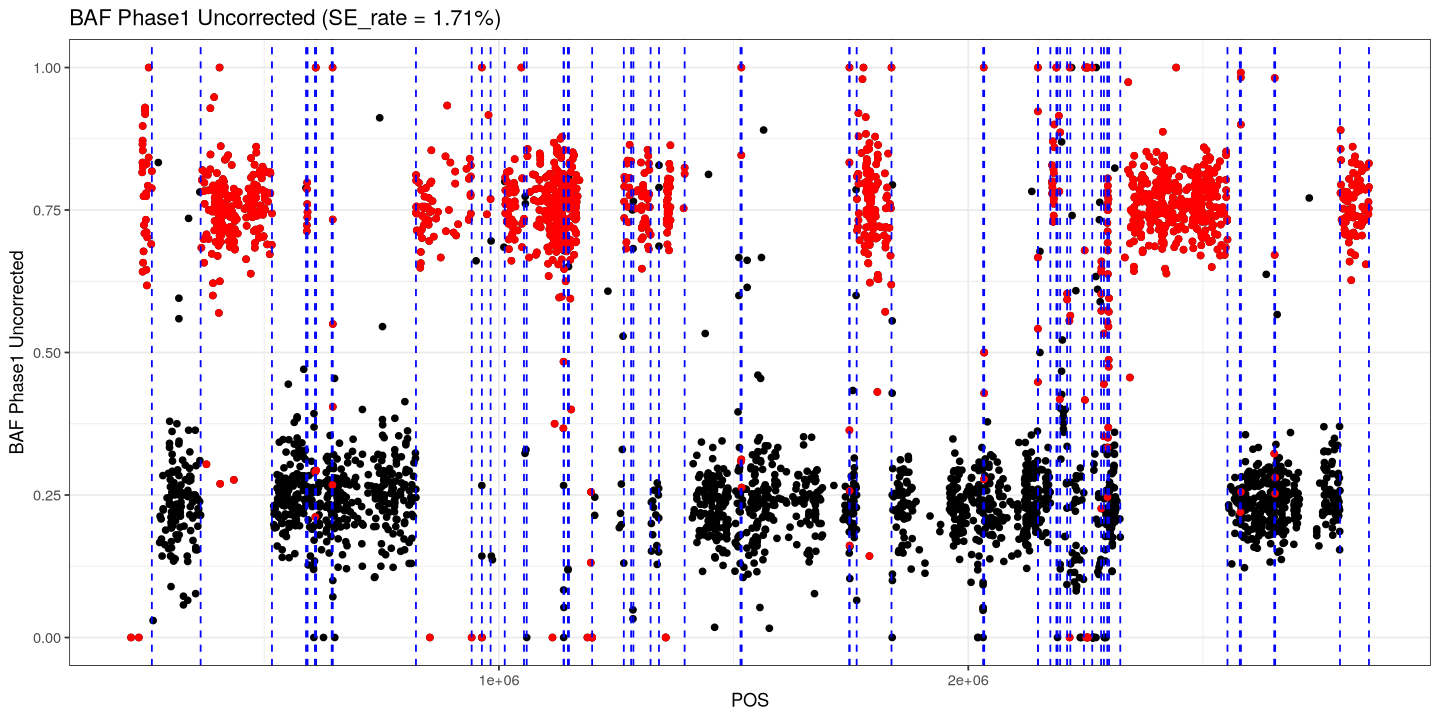

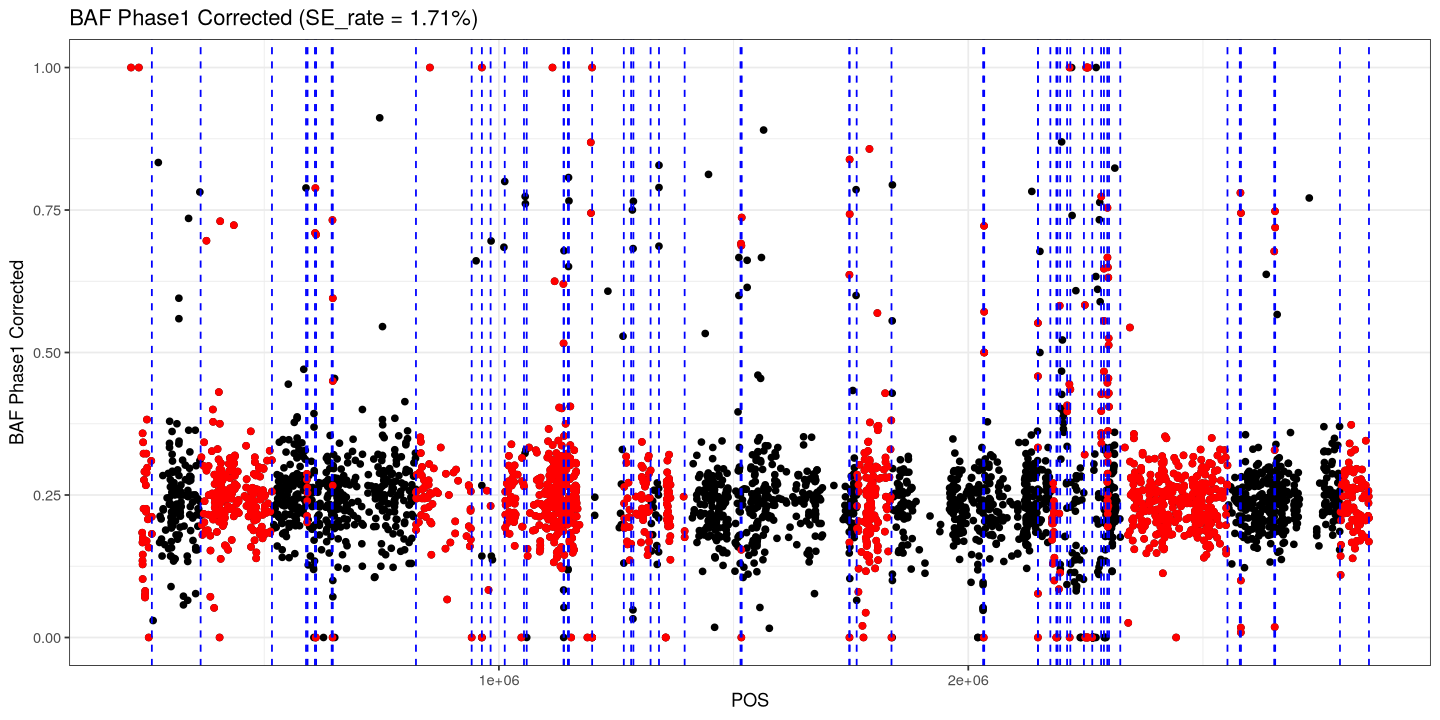

In [8]:

res_low_coverage = compute_SE_IZ (segment_CN, 
                  segment_beagle,
                  chr,
                  minor_cn, major_cn, total_cn,
                  gamma = 1,
                  minEvents = 5,
                  llr_thresh = 0,
                  min_run = 5,
                  window = 21,
                  plot_result = TRUE)
    
    
res_low_coverage$SE_rate
res_low_coverage$plots$uncorrected
res_low_coverage$plots$corrected

### High coverage 1kGp phasing

In [11]:
input_path_PCAWG = read.table("/srv/home/mlef0011/Phasomix/output/local_ancestry/prediction/high_coverage/IS_corrected/input_path_F1_like_mono_x_admixed_gnomix_PCAWG_POP_no_AMR.tsv", header=T, sep = "\t")
samples = input_path_PCAWG$sample

chr = 8


allecount_path <- paste0("/mnt/iribhm/globus/secure/PCAWG_alleleCounts/", sample, "/", sample, "_alleleFrequencies_chr", chr, ".txt.gz")

beagle_mixed_ancestry = fread("/srv/home/mlef0011/Phasomix/rawdata/PCAWG/rawdata/chr8_PCAWG_beagle5_subset_1kgp_PCAWG_snp_phased_1kGp_unrelared_IDs_high_coverage_reference_panel.vcf.gz", select = c('#CHROM','POS','ID','REF','ALT','QUAL','FILTER','INFO','FORMAT',sample), skip = "#CHROM", header=T, sep = "\t", data.table=F)
beagle_raw <- beagle_mixed_ancestry[, c(colnames(beagle_mixed_ancestry)[1:9], sample)]
beagle <- beagle_raw[beagle_raw[[ncol(beagle_raw)]] != "0|0", ]

baf_raw <- get_baf(sample, chr, allecount_path, beagle)


common_pos <- intersect(beagle$POS, baf_raw$POS)

beagle <- beagle[match(common_pos, beagle$POS), ]
baf <- baf_raw[match(common_pos, baf_raw$POS), ]

colnames(beagle)[ncol(beagle)] = sample
corrected_beagle_correction_1 = beagle
corrected_beagle_correction_2 = beagle


cna_file = input_path_PCAWG[input_path_PCAWG$sample == sample , "input_CNA"]
cna <- fread(cna_file, sep = '\t', data.table = FALSE)
iz = subset(cna, chromosome == chr & !is.na(major_cn) & !is.na(minor_cn) & minor_cn != major_cn)[,1:6]

idx = 1
start = iz[idx,2]
end = iz[idx,3]
minor_cn = iz[idx,5]
major_cn = iz[idx,6]
total_cn = iz[idx,4]

segment_beagle = subset(beagle, beagle$'#CHROM' == chr & beagle$POS >= start & beagle$POS <= end)
segment_CN = subset(baf, beagle$'#CHR' == chr & baf$POS >= start & baf$POS <= end)

[1] 1.043608

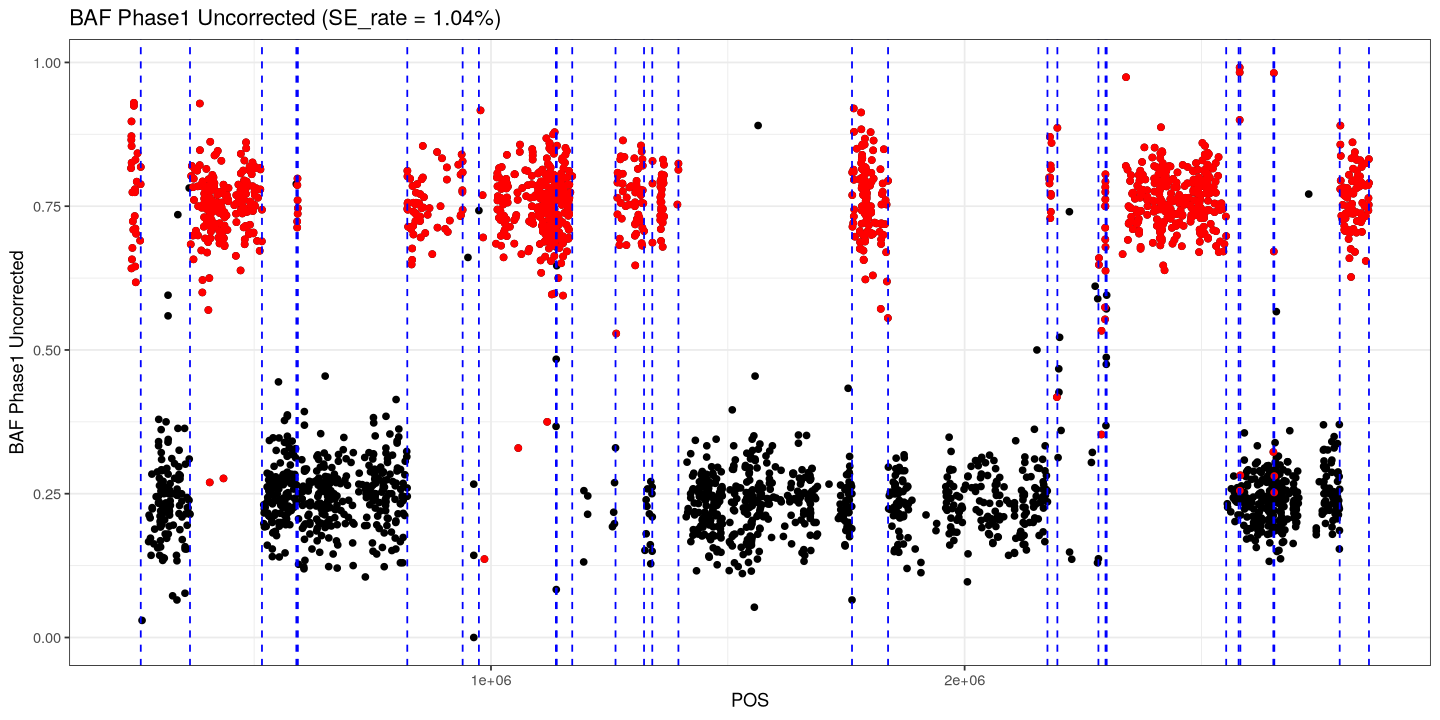

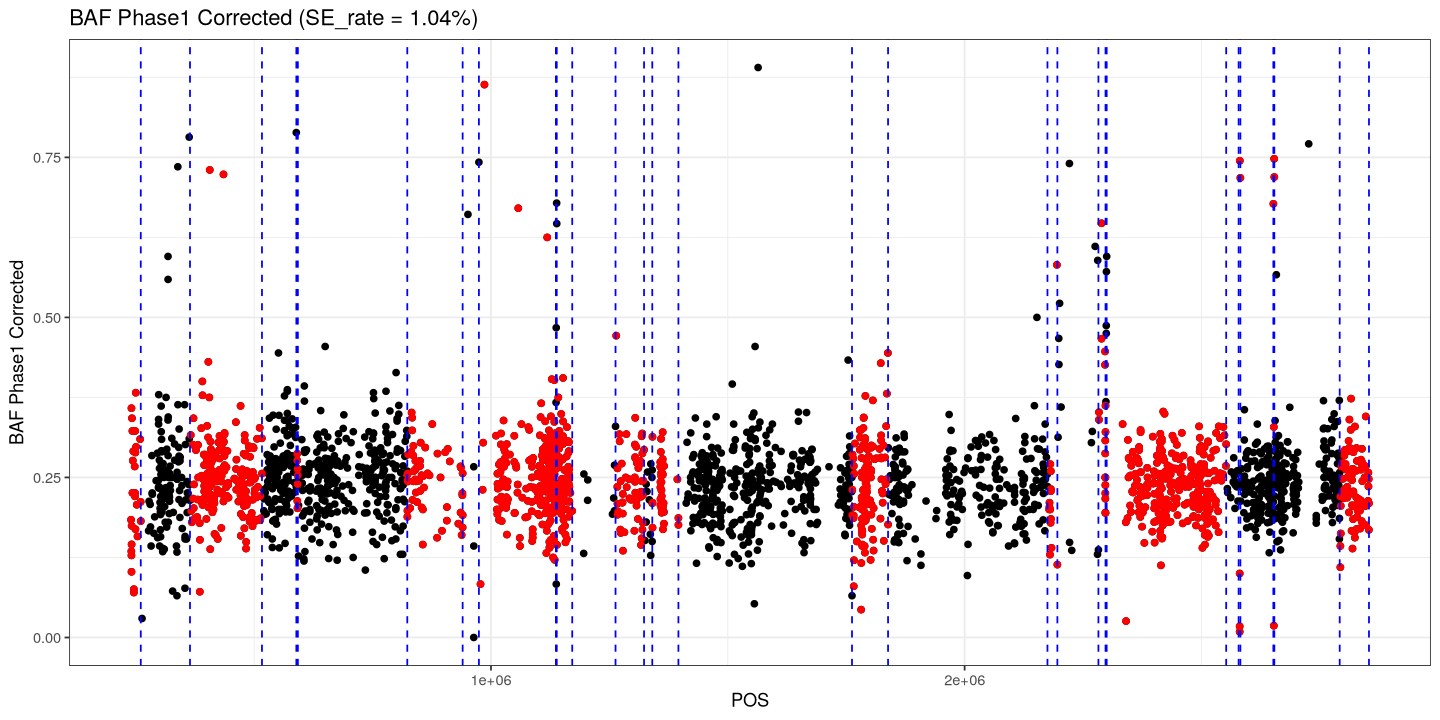

In [12]:
res_high_coverage = compute_SE_IZ (segment_CN, 
                  segment_beagle,
                  chr,
                  minor_cn, major_cn, total_cn,
                  gamma = 1,
                  minEvents = 5,
                  llr_thresh = 0,
                  min_run = 5,
                  window = 21,
                  plot_result = TRUE)
    
    
res_high_coverage$SE_rate
res_high_coverage$plots$uncorrected
res_high_coverage$plots$corrected

# Compare results SE rate in IZ with different reference panel for phasing

pdf 
  2

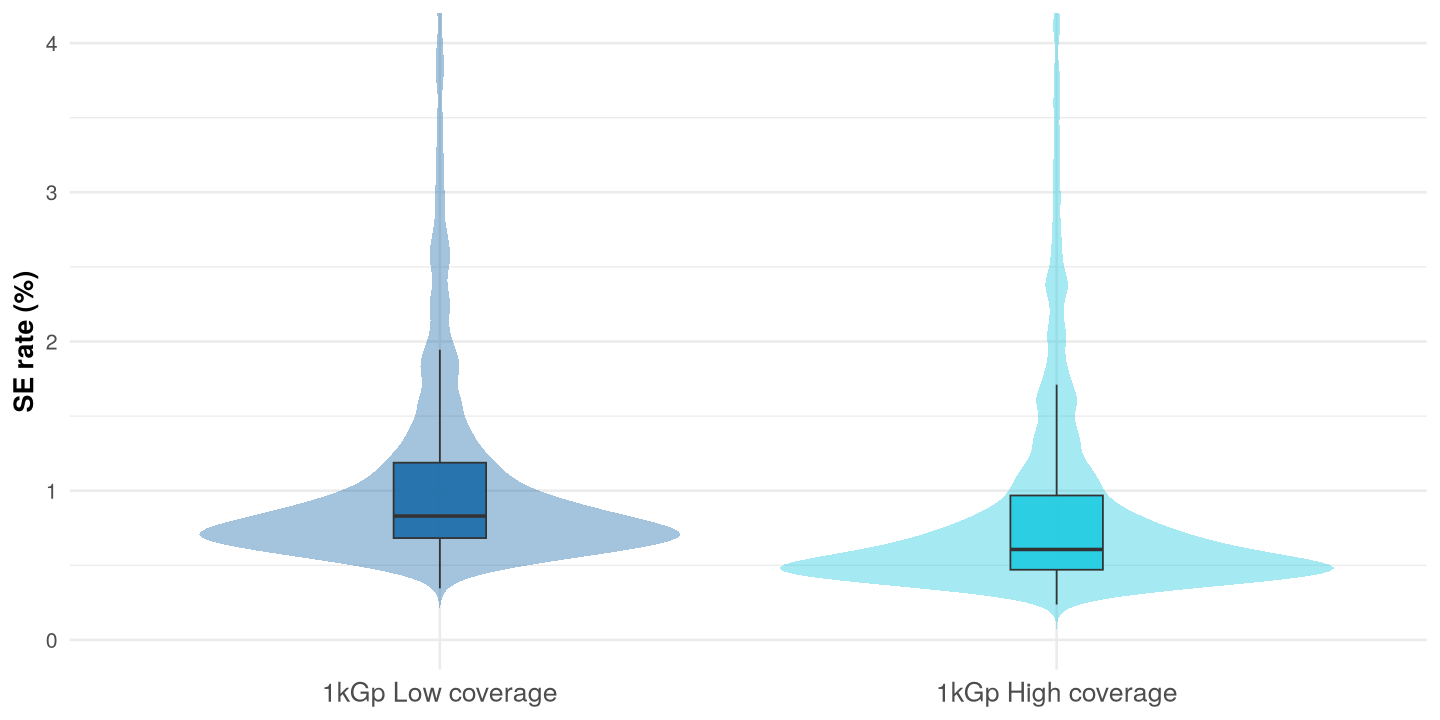

In [4]:
high_coverage_SE = read.table("/srv/home/mlef0011/Phasomix/rawdata/PCAWG/vcf_corrected/high_coverage_unrelated_1kGp/PCAWG_SE_correction_summary.txt", header=T, sep = "\t")
low_coverage_SE = read.table('/srv/home/mlef0011/Phasomix/rawdata/PCAWG/vcf_corrected/low_coverage_unrelated_1kGp/PCAWG_SE_correction_summary.txt', header=T, sep = "\t")

#high_coverage_SE = high_coverage_SE[high_coverage_SE$n_hz_snps > 1000,]
#low_coverage_SE = low_coverage_SE[low_coverage_SE$n_hz_snps > 1000,]


high_coverage_SE_mean <- high_coverage_SE %>%
  group_by(sample) %>%
  filter(sum(n_iz) > 10) %>%
  filter(sum(n_hz_snps) > 10000) %>%
  summarise(
    SE_rate_mean = sum(se_rate * n_hz_snps) / sum(n_hz_snps),
    .groups = "drop"
  )

low_coverage_SE_mean <- low_coverage_SE %>%
  group_by(sample) %>%
  filter(sum(n_iz) > 10) %>%
  filter(sum(n_hz_snps) > 10000) %>%
  summarise(
    SE_rate_mean = sum(se_rate * n_hz_snps) / sum(n_hz_snps),
    .groups = "drop"
  )

high_coverage_SE_mean$group <- "1kGp High coverage"
low_coverage_SE_mean$group = "1kGp Low coverage"

# Fusionner les deux dataframes
df_all <- bind_rows(low_coverage_SE_mean, high_coverage_SE_mean)
df_all$group <- factor(df_all$group, levels = c("1kGp Low coverage", "1kGp High coverage"))

# Créer le boxplot
plot = ggplot(df_all, aes(x = group, y = SE_rate_mean, fill = group)) +
  geom_violin(trim = FALSE, alpha = 0.4, color = NA) +
  geom_boxplot(width = 0.15, outlier.shape = NA, alpha = 0.9) +
  scale_fill_manual(values = c("1kGp Low coverage" = "#1b6ca8",
                               "1kGp High coverage" = "#1ecbe1")) +
  labs(x = NULL, y = "SE rate (%)") +
  coord_cartesian(ylim = c(0, 4)) +
  theme_minimal(base_size = 16) +
  theme(
    legend.position = "none",
    axis.text.x = element_text(size = 16),
    axis.title.y = element_text(size = 16, face = "bold")
  )

plot

svg("/srv/home/mlef0011/Phasomix/output/figures/SER_accuracy.svg",
               width = 6, height = 4)
print(plot)
dev.off()

In [7]:
summary(df_all$SE_rate_mean[df_all$group == "Low coverage"])
summary(df_all$SE_rate_mean[df_all$group == "High coverage"])

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.3459  0.6825  0.8302  1.1451  1.1879 10.5377 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.2373  0.4703  0.6062  0.9375  0.9680 10.6302 

In [10]:
0.8302 - (0.8302*0.27)
100-0.6062/0.8302*100

[1] 0.606046

[1] 26.98145

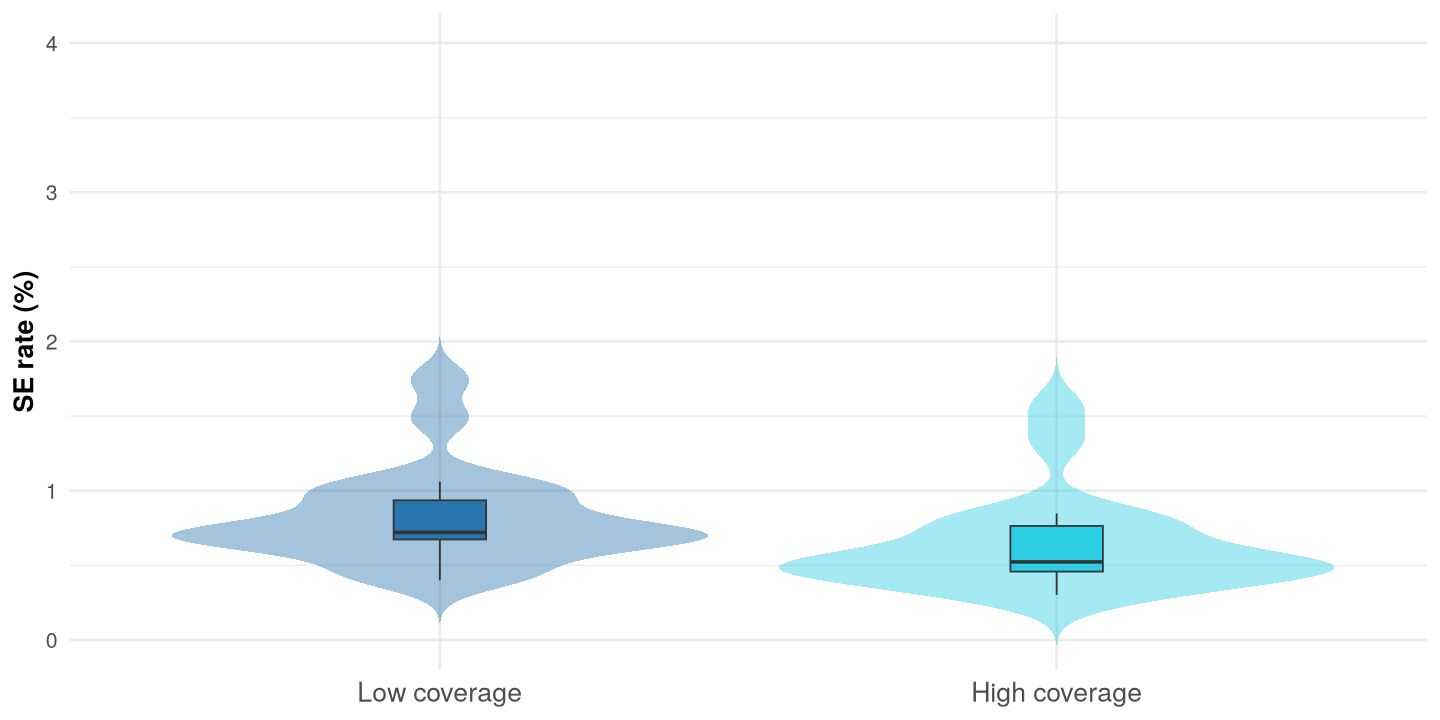

In [101]:
info_ma = read.table("/srv/home/mlef0011/Phasomix/output/local_ancestry/prediction/high_coverage/IS_corrected/input_path_F1_like_mono_x_admixed_gnomix_PCAWG_POP_no_AMR.tsv", header=T, sep = "\t")
samples = info_ma$sample

high_coverage_SE = read.table("/srv/home/mlef0011/Phasomix/rawdata/PCAWG/vcf_corrected/high_coverage_unrelated_1kGp/PCAWG_SE_correction_summary.txt", header=T, sep = "\t")
low_coverage_SE = read.table('/srv/home/mlef0011/Phasomix/rawdata/PCAWG/vcf_corrected/low_coverage_unrelated_1kGp/PCAWG_SE_correction_summary.txt', header=T, sep = "\t")

high_coverage_SE = high_coverage_SE[high_coverage_SE$sample %in% samples,]
low_coverage_SE = low_coverage_SE[low_coverage_SE$sample %in% samples,]

high_coverage_SE_mean <- high_coverage_SE %>%
  group_by(sample) %>%
  filter(sum(n_iz) > 10) %>%
  filter(sum(n_hz_snps) > 10000) %>%
  summarise(
    SE_rate_mean = sum(se_rate * n_hz_snps) / sum(n_hz_snps),
    .groups = "drop"
  )

low_coverage_SE_mean <- low_coverage_SE %>%
  group_by(sample) %>%
  filter(sum(n_iz) > 10) %>%
  filter(sum(n_hz_snps) > 10000) %>%
  summarise(
    SE_rate_mean = sum(se_rate * n_hz_snps) / sum(n_hz_snps),
    .groups = "drop"
  )

high_coverage_SE_mean$group <- "High coverage"
low_coverage_SE_mean$group = "Low coverage"

# Fusionner les deux dataframes
df_all <- bind_rows(low_coverage_SE_mean, high_coverage_SE_mean)
df_all$group <- factor(df_all$group, levels = c("Low coverage", "High coverage"))

# Créer le boxplot
plot = ggplot(df_all, aes(x = group, y = SE_rate_mean, fill = group)) +
  geom_violin(trim = FALSE, alpha = 0.4, color = NA) +
  geom_boxplot(width = 0.15, outlier.shape = NA, alpha = 0.9) +
  scale_fill_manual(values = c("Low coverage" = "#1b6ca8",
                               "High coverage" = "#1ecbe1")) +
  labs(x = NULL, y = "SE rate (%)") +
  coord_cartesian(ylim = c(0, 4)) +
  theme_minimal(base_size = 16) +
  theme(
    legend.position = "none",
    axis.text.x = element_text(size = 16),
    axis.title.y = element_text(size = 16, face = "bold")
  )

plot